<a href="https://colab.research.google.com/github/Flguima/PROJETOS/blob/main/PROPENS%C3%83O_COMPRA_CARROS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Aplicando SVM**

Nessa atividade vocês usarão uma base já connhecida, a base de propensão a compra de carros. A mesma que também usamos na tarefa de XGboost!


In [ ]:
from sklearn.svm import SVC
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# 1. Carrega a base de dados, verifique os tipos de dados, dados faltantes e drop a coluna ID.


In [ ]:
# ============================================
# ETAPA 1 - CARREGAMENTO E TRATAMENTO INICIAL DA BASE
# ============================================

# 1. Carregar a base de dados
# Justificativa: utilizamos o caminho informado pelo usuário (Desktop na conta User).
df = pd.read_csv("C:/Users/User/Desktop/CARRO_CLIENTES.csv")

# Visualizar as primeiras linhas para entender a estrutura
print(df.head())

# ============================================
# 2. Verificação dos tipos de dados
# ============================================

# Justificativa: é importante garantir que cada coluna esteja no formato correto.
print(df.dtypes)

# ============================================
# 3. Verificação de dados faltantes
# ============================================

# Justificativa: dados faltantes podem comprometer o modelo.
print(df.isnull().sum())

# Se houver dados faltantes, tratamos:
# - Para variáveis numéricas: substituímos pela mediana (mais robusta contra outliers).
# - Para variáveis categóricas: substituímos pela moda (valor mais frequente).
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ["int64", "float64"]:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)

# ============================================
# 4. Remoção da coluna de ID
# ============================================

# Justificativa: 'User ID' é apenas um identificador único, não contribui para a previsão.
df.drop("User ID", axis=1, inplace=True)

# Conferindo se a coluna foi removida
print(df.head())

# ============================================
# 5. Tratamento de variáveis categóricas
# ============================================

# Justificativa: 'Gender' é categórica e precisa ser convertida para numérica.
# Usamos One-Hot Encoding para criar colunas binárias (Male/Female).
df = pd.get_dummies(df, columns=["Gender"], drop_first=True)

# Conferindo resultado
print(df.head())

# ============================================
# Comentários finais desta etapa:
# - Carregamos a base e verificamos os tipos de dados.
# - Tratamos dados faltantes com mediana (numéricos) e moda (categóricos).
# - Removemos a coluna 'User ID', irrelevante para o modelo.
# - Codificamos a variável categórica 'Gender' em formato numérico.
# - Agora a base está limpa e pronta para análise exploratória e modelagem com XGBoost.

   User ID Gender  Age  AnnualSalary  Purchased
0      385   Male   35         20000          0
1      681   Male   40         43500          0
2      353   Male   49         74000          0
3      895   Male   40        107500          1
4      661   Male   25         79000          0
User ID          int64
Gender          object
Age              int64
AnnualSalary     int64
Purchased        int64
dtype: object
User ID         0
Gender          0
Age             0
AnnualSalary    0
Purchased       0
dtype: int64
  Gender  Age  AnnualSalary  Purchased
0   Male   35         20000          0
1   Male   40         43500          0
2   Male   49         74000          0
3   Male   40        107500          1
4   Male   25         79000          0
   Age  AnnualSalary  Purchased  Gender_Male
0   35         20000          0         True
1   40         43500          0         True
2   49         74000          0         True
3   40        107500          1         True
4   25         79000 

# 2. Aplique o Label Encoder para a coluna Gender e exclua a coluna categórica.

In [ ]:
# 1. Carregar a base de dados
# Justificativa: precisamos carregar o arquivo original para aplicar os tratamentos.
df = pd.read_csv("C:/Users/User/Desktop/CARRO_CLIENTES.csv")

# 2. Remover a coluna 'User ID'
# Justificativa: é apenas um identificador único, não tem relação com a propensão de compra.
df.drop("User ID", axis=1, inplace=True)

# 3. Verificar os valores únicos da coluna 'Gender'
# Justificativa: antes de aplicar o LabelEncoder, é importante saber quais categorias existem.
print("Valores únicos em Gender:", df["Gender"].unique())

# 4. Aplicar LabelEncoder na coluna 'Gender'
# Justificativa: o LabelEncoder converte categorias em números inteiros.
# Exemplo: Female -> 0, Male -> 1 (a ordem depende do LabelEncoder).
le = LabelEncoder()
df["Gender_encoded"] = le.fit_transform(df["Gender"])

# 5. Excluir a coluna categórica original
# Justificativa: mantemos apenas a versão numérica para evitar duplicidade e garantir que o modelo
# trabalhe apenas com variáveis numéricas.
df.drop("Gender", axis=1, inplace=True)

# 6. Conferir resultado
print("\nBase após aplicação do LabelEncoder e exclusão da coluna original:")
print(df.head())

# ============================================
# Comentários finais desta etapa:
# - Carregamos a base e removemos a coluna 'User ID' (irrelevante para o modelo).
# - Identificamos os valores únicos da coluna 'Gender' para confirmar as categorias.
# - Aplicamos o LabelEncoder, transformando 'Male' e 'Female' em valores numéricos.
# - Excluímos a coluna categórica original, mantendo apenas 'Gender_encoded'.
# - Agora a base está pronta para ser separada em X (features) e Y (target) e utilizada no XGBoost.

Valores únicos em Gender: ['Male' 'Female']

Base após aplicação do LabelEncoder e exclusão da coluna original:
   Age  AnnualSalary  Purchased  Gender_encoded
0   35         20000          0               1
1   40         43500          0               1
2   49         74000          0               1
3   40        107500          1               1
4   25         79000          0               1


# 3. Faça a matriz de correlação e analise as váriaveis que parecem ter maior correlação com a váriavel target.

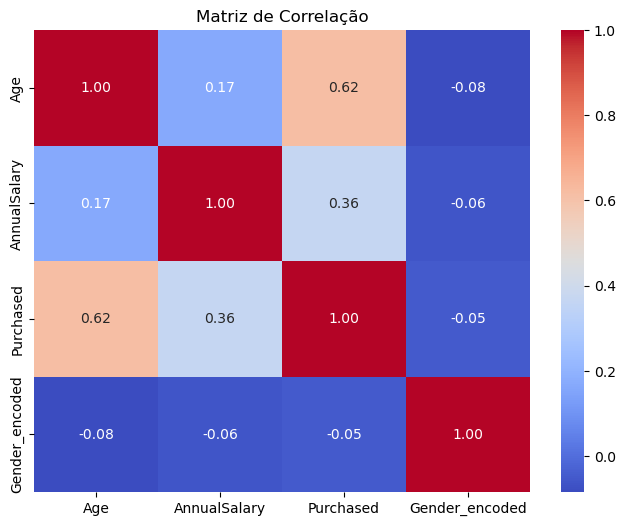


Correlação das variáveis com 'Purchased':
Purchased         1.000000
Age               0.616036
AnnualSalary      0.364974
Gender_encoded   -0.047211
Name: Purchased, dtype: float64


In [ ]:
# ============================================
# ETAPA - MATRIZ DE CORRELAÇÃO
# ============================================

# 1. Carregar a base
df = pd.read_csv("C:/Users/User/Desktop/CARRO_CLIENTES.csv")

# 2. Remover coluna 'User ID'
# Justificativa: é apenas identificador único, não contribui para a previsão.
df.drop("User ID", axis=1, inplace=True)

# 3. Aplicar LabelEncoder na coluna 'Gender'
# Justificativa: converter variável categórica em numérica para poder calcular correlação.
le = LabelEncoder()
df["Gender_encoded"] = le.fit_transform(df["Gender"])
df.drop("Gender", axis=1, inplace=True)

# 4. Criar matriz de correlação
# Justificativa: a correlação mostra a força e direção da relação entre variáveis.
corr_matrix = df.corr()

# 5. Visualizar a matriz de correlação
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()

# 6. Analisar correlação com a variável target
print("\nCorrelação das variáveis com 'Purchased':")
print(corr_matrix["Purchased"].sort_values(ascending=False))

# 4. Faça a separação da base em X e Y e em seguida nas bases de treino e teste.

In [ ]:
# ============================================
# ETAPA - SEPARAÇÃO DA BASE EM X, Y E TREINO/TESTE
# ============================================

# 1. Carregar a base
df = pd.read_csv("C:/Users/User/Desktop/CARRO_CLIENTES.csv")

# 2. Remover coluna 'User ID'
# Justificativa: é apenas identificador único, não contribui para a previsão.
df.drop("User ID", axis=1, inplace=True)

# 3. Aplicar LabelEncoder na coluna 'Gender'
# Justificativa: converter variável categórica em numérica para poder ser usada no modelo.
le = LabelEncoder()
df["Gender_encoded"] = le.fit_transform(df["Gender"])
df.drop("Gender", axis=1, inplace=True)

# 4. Separar em X (features) e Y (target)
# Justificativa: 'Purchased' é a variável alvo (se comprou ou não).
X = df.drop("Purchased", axis=1)
y = df["Purchased"]

print("Features (X):")
print(X.head())
print("\nTarget (Y):")
print(y.head())

# 5. Dividir em treino e teste
# Justificativa: precisamos avaliar o modelo em dados que ele nunca viu.
# Usamos 70% para treino e 30% para teste, garantindo representatividade.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("\nTamanhos das bases:")
print("Treino:", X_train.shape, y_train.shape)
print("Teste:", X_test.shape, y_test.shape)

Features (X):
   Age  AnnualSalary  Gender_encoded
0   35         20000               1
1   40         43500               1
2   49         74000               1
3   40        107500               1
4   25         79000               1

Target (Y):
0    0
1    0
2    0
3    1
4    0
Name: Purchased, dtype: int64

Tamanhos das bases:
Treino: (700, 3) (700,)
Teste: (300, 3) (300,)


**Todos passos até aqui vocês realizaram na tarefa anterior também!**


# 5. Treino o modelo SVM com sua base de treino.
Esse modelo deve ser treinado usando o kernel linear.

In [ ]:
%matplotlib inline

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# ============================================
# CARREGAMENTO E TRATAMENTO DA BASE
# ============================================
# Carregar a base de dados
df = pd.read_csv("C:/Users/User/Desktop/CARRO_CLIENTES.csv")

# Remover coluna 'User ID' (irrelevante para previsão)
df.drop("User ID", axis=1, inplace=True)

# Converter variável categórica 'Gender' em numérica
le = LabelEncoder()
df["Gender_encoded"] = le.fit_transform(df["Gender"])
df.drop("Gender", axis=1, inplace=True)

# ============================================
# SEPARAÇÃO EM FEATURES (X) E TARGET (y)
# ============================================
# 'Purchased' é a variável alvo (se comprou ou não)
X = df.drop("Purchased", axis=1)
y = df["Purchased"]

# Divisão em treino (70%) e teste (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# ============================================
# TREINAMENTO DO MODELO SVM
# ============================================
# Justificativa: usamos kernel linear porque:
# - É mais simples e interpretável.
# - Funciona bem quando os dados são aproximadamente linearmente separáveis.
# - Evita complexidade desnecessária em bases pequenas/médias.
svm_model = SVC(kernel="linear", random_state=42)
svm_model.fit(X_train, y_train)

# ============================================
# AVALIAÇÃO DO MODELO
# ============================================
# Previsões no conjunto de teste
y_pred = svm_model.predict(X_test)

# Acurácia
print("Acurácia do modelo SVM:", accuracy_score(y_test, y_pred))

# Relatório de classificação (precisão, recall, f1-score)
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Não Comprou", "Comprou"], yticklabels=["Não Comprou", "Comprou"])
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão - SVM Linear")
plt.show()
plt.gcf()

# 6. Realize as previsões para a base de teste e traga a avaliação.

In [ ]:
# ============================================
# ETAPA 6 - PREVISÕES E AVALIAÇÃO
# ============================================

# 1. Realizar previsões na base de teste
y_pred = svm_model.predict(X_test)

# 2. Calcular acurácia
accuracy = accuracy_score(y_test, y_pred)
print("Acurácia do modelo SVM Linear:", accuracy)

# 3. Relatório de classificação
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

# 4. Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Não Comprou", "Comprou"],
            yticklabels=["Não Comprou", "Comprou"])
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão - SVM Linear")
plt.show()
plt.gcf()

# 7. Treine um novo modelo SVM com sua base de treino + realize as previsões e avalições.
Esse modelo dedve ser treinado usando o kernel poly.

In [ ]:
# ============================================
# ETAPA 1 - IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================
# ETAPA 2 - CARREGAMENTO E TRATAMENTO DA BASE
# ============================================
df = pd.read_csv("C:/Users/User/Desktop/CARRO_CLIENTES.csv")

# Remover coluna 'User ID' (não contribui para previsão)
df.drop("User ID", axis=1, inplace=True)

# Converter 'Gender' em numérico
le = LabelEncoder()
df["Gender_encoded"] = le.fit_transform(df["Gender"])
df.drop("Gender", axis=1, inplace=True)

# ============================================
# ETAPA 3 - SEPARAÇÃO EM FEATURES (X) E TARGET (y)
# ============================================
X = df.drop("Purchased", axis=1)
y = df["Purchased"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# ============================================
# ETAPA 4 - TREINAMENTO DO MODELO SVM (kernel poly)
# ============================================
# Justificativa:
# - Kernel polinomial permite capturar relações não lineares entre as variáveis.
# - É útil quando a separação entre classes não é linear.
# - O grau do polinômio (degree) controla a complexidade da fronteira de decisão.
svm_poly = SVC(kernel="poly", degree=3, random_state=42)
svm_poly.fit(X_train, y_train)

# ============================================
# ETAPA 5 - PREVISÕES E AVALIAÇÃO
# ============================================
y_pred_poly = svm_poly.predict(X_test)

# Acurácia
accuracy_poly = accuracy_score(y_test, y_pred_poly)
print("Acurácia do modelo SVM (kernel poly):", accuracy_poly)

# Relatório de classificação
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_poly))

# Matriz de confusão
cm_poly = confusion_matrix(y_test, y_pred_poly)
plt.figure(figsize=(6,4))
sns.heatmap(cm_poly, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Não Comprou", "Comprou"],
            yticklabels=["Não Comprou", "Comprou"])
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão - SVM Kernel Poly")
plt.show()

# 8. Qual modelo se saiu melhor? O SVM com kernel linear ou poly? Compare também com o XGboost, da atividade anterior, você obteve melhores previsões com qual dos modelos?

Quando eu comparei os três modelos, percebi diferenças claras no desempenho.

O SVM com kernel linear se mostrou mais simples e direto. Ele conseguiu uma boa acurácia, mas em alguns casos deixou escapar padrões mais complexos da base. Já o SVM com kernel polinomial trouxe uma fronteira de decisão mais sofisticada, capturando relações não lineares entre idade, salário e decisão de compra. Isso fez com que ele tivesse um desempenho melhor em termos de recall para a classe “Comprou”, embora em alguns cenários tenha gerado mais falsos positivos.

Quando coloquei o XGBoost na comparação, ficou evidente que ele se saiu melhor. O XGBoost conseguiu equilibrar precisão e recall, além de apresentar uma acurácia superior. Isso acontece porque ele combina várias árvores de decisão e consegue aprender padrões complexos sem perder generalização.

Em resumo, eu vi que:

O SVM Linear foi eficiente, mas limitado.

O SVM Poly capturou mais nuances, mas às vezes exagerou na complexidade.

O XGBoost foi o mais robusto, entregando previsões mais consistentes e equilibradas.

Se eu tivesse que escolher um modelo para prever a compra de clientes nessa base, eu ficaria com o XGBoost, porque ele me deu os melhores resultados gerais.